<a href="https://colab.research.google.com/github/sabdaipry/fiuba-ceia-pln1/blob/main/Desafio_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Custom embedddings con Gensim



### Objetivo
El objetivo es utilizar documentos / corpus para crear embeddings de palabras basado en ese contexto. Se utilizará canciones de bandas para generar los embeddings, es decir, que los vectores tendrán la forma en función de como esa banda haya utilizado las palabras en sus canciones.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import multiprocessing
try:
  from gensim.models import Word2Vec
except:
  !pip install gensim
  from gensim.models import Word2Vec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 40.0 MB/s eta 0:00:00


### Datos
Utilizaremos como dataset canciones de bandas de habla inglesa.

In [ ]:
# Descargar la carpeta de dataset
import os
import platform
if os.access('./songs_dataset', os.F_OK) is False:
    if os.access('songs_dataset.zip', os.F_OK) is False:
        if platform.system() == 'Windows':
            !curl https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip -o songs_dataset.zip
        else:
            !wget songs_dataset.zip https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip
    !unzip -q songs_dataset.zip
else:
    print("El dataset ya se encuentra descargado")

--2026-04-17 12:52:17--  http://songs_dataset.zip/
Resolving songs_dataset.zip (songs_dataset.zip)... failed: Name or service not known.
wget: unable to resolve host address ‘songs_dataset.zip’
--2026-04-17 12:52:17--  https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip [following]
--2026-04-17 12:52:17--  https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.

In [ ]:
# Posibles bandas
os.listdir("./songs_dataset/")

['michael-jackson.txt',
 'notorious-big.txt',
 'drake.txt',
 'adele.txt',
 'radiohead.txt',
 'nirvana.txt',
 'paul-simon.txt',
 'dj-khaled.txt',
 'joni-mitchell.txt',
 'amy-winehouse.txt',
 'Kanye_West.txt',
 'Lil_Wayne.txt',
 'bjork.txt',
 'bob-marley.txt',
 'lin-manuel-miranda.txt',
 'prince.txt',
 'lil-wayne.txt',
 'lady-gaga.txt',
 'lorde.txt',
 'kanye-west.txt',
 'patti-smith.txt',
 'leonard-cohen.txt',
 'nicki-minaj.txt',
 'rihanna.txt',
 'britney-spears.txt',
 'al-green.txt',
 'kanye.txt',
 'alicia-keys.txt',
 'nursery_rhymes.txt',
 'bob-dylan.txt',
 'r-kelly.txt',
 'cake.txt',
 'eminem.txt',
 'missy-elliott.txt',
 'johnny-cash.txt',
 'disney.txt',
 'blink-182.txt',
 'bruno-mars.txt',
 'dickinson.txt',
 'dr-seuss.txt',
 'bruce-springsteen.txt',
 'janisjoplin.txt',
 'ludacris.txt',
 'dolly-parton.txt',
 'jimi-hendrix.txt',
 'beatles.txt',
 'bieber.txt',
 'nickelback.txt',
 'notorious_big.txt']

In [ ]:
# Armar el dataset utilizando salto de línea para separar las oraciones/docs
df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)
df.head()

/tmp/ipykernel_11607/3849064916.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)


,0
0,"Yesterday, all my troubles seemed so far away"
1,Now it looks as though they're here to stay
2,"Oh, I believe in yesterday Suddenly, I'm not h..."
3,There's a shadow hanging over me.
4,"Oh, yesterday came suddenly Why she had to go ..."


In [ ]:
print("Cantidad de documentos:", df.shape[0])

Cantidad de documentos: 1846


### 1 - Preprocesamiento

In [ ]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence

sentence_tokens = []
# Recorrer todas las filas y transformar las oraciones
# en una secuencia de palabras (esto podría realizarse con NLTK o spaCy también)
for _, row in df[:None].iterrows():
    sentence_tokens.append(text_to_word_sequence(row[0]))

In [ ]:
# Demos un vistazo
sentence_tokens[:2]

[['yesterday', 'all', 'my', 'troubles', 'seemed', 'so', 'far', 'away'],
 ['now', 'it', 'looks', 'as', 'though', "they're", 'here', 'to', 'stay']]

### 2 - Crear los vectores (word2vec)

In [ ]:
from gensim.models.callbacks import CallbackAny2Vec
# Durante el entrenamiento gensim por defecto no informa el "loss" en cada época
# Sobrecargamos el callback para poder tener esta información
class callback(CallbackAny2Vec):
    """
    Callback to print loss after each epoch
    """
    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print('Loss after epoch {}: {}'.format(self.epoch, loss))
        else:
            print('Loss after epoch {}: {}'.format(self.epoch, loss- self.loss_previous_step))
        self.epoch += 1
        self.loss_previous_step = loss

In [ ]:
# Crearmos el modelo generador de vectores
# En este caso utilizaremos la estructura modelo Skipgram
w2v_model = Word2Vec(min_count=5,    # frecuencia mínima de palabra para incluirla en el vocabulario
                     window=2,       # cant de palabras antes y desp de la predicha
                     vector_size=300,       # dimensionalidad de los vectores
                     negative=20,    # cantidad de negative samples... 0 es no se usa
                     workers=1,      # si tienen más cores pueden cambiar este valor
                     sg=1)           # modelo 0:CBOW  1:skipgram

In [ ]:
# Obtener el vocabulario con los tokens
w2v_model.build_vocab(sentence_tokens)

In [ ]:
# Cantidad de filas/docs encontradas en el corpus
print("Cantidad de docs en el corpus:", w2v_model.corpus_count)

Cantidad de docs en el corpus: 1846


In [ ]:
# Cantidad de words encontradas en el corpus
print("Cantidad de words distintas en el corpus:", len(w2v_model.wv.index_to_key))

Cantidad de words distintas en el corpus: 445


### 3 - Entrenar embeddings

In [ ]:
# Entrenamos el modelo generador de vectores
# Utilizamos nuestro callback
w2v_model.train(sentence_tokens,
                 total_examples=w2v_model.corpus_count,
                 epochs=20,
                 compute_loss = True,
                 callbacks=[callback()]
                 )

Loss after epoch 0: 113045.25
Loss after epoch 1: 65966.59375
Loss after epoch 2: 65934.984375
Loss after epoch 3: 65718.390625
Loss after epoch 4: 63875.09375
Loss after epoch 5: 64160.65625
Loss after epoch 6: 64080.21875
Loss after epoch 7: 64814.875
Loss after epoch 8: 62632.75
Loss after epoch 9: 60452.875
Loss after epoch 10: 59839.875
Loss after epoch 11: 58884.375
Loss after epoch 12: 57715.75
Loss after epoch 13: 56494.3125
Loss after epoch 14: 55817.5
Loss after epoch 15: 55842.9375
Loss after epoch 16: 51722.4375
Loss after epoch 17: 49858.0
Loss after epoch 18: 49592.25
Loss after epoch 19: 48960.125


(156986, 287740)

### 4 - Ensayar

In [ ]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["darling"], topn=10)

[('pretty', 0.8954247832298279),
 ('sleep', 0.8665655851364136),
 ('help', 0.8439376354217529),
 ('cry', 0.8351269960403442),
 ('not', 0.8309612274169922),
 ('try', 0.8276943564414978),
 ('peace', 0.8144856691360474),
 ('little', 0.8140572309494019),
 ('twist', 0.8123919367790222),
 ('seems', 0.8079564571380615)]

In [ ]:
# Palabras que MENOS se relacionan con...:
w2v_model.wv.most_similar(negative=["love"], topn=10)

[('shake', -0.22873197495937347),
 ('four', -0.2330218255519867),
 ('five', -0.23746445775032043),
 ('six', -0.23784494400024414),
 ('bang', -0.24832050502300262),
 ('our', -0.25539135932922363),
 ('day', -0.2689811885356903),
 ('going', -0.2692062556743622),
 ('here', -0.26990723609924316),
 ('three', -0.2838989198207855)]

In [ ]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["four"], topn=10)

[('five', 0.9813723564147949),
 ('three', 0.9745770692825317),
 ('six', 0.9710808992385864),
 ('seven', 0.9584357738494873),
 ('two', 0.9517216682434082),
 ('sixty', 0.8990395665168762),
 ('one', 0.7951181530952454),
 ('crying', 0.7946289777755737),
 ('us', 0.7740051746368408),
 ("i'm", 0.7508383393287659)]

In [ ]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["money"], topn=5)

[("can't", 0.9434017539024353),
 ('buy', 0.9396998882293701),
 ('much', 0.9033146500587463),
 ('just', 0.8509082198143005),
 ('hide', 0.835538387298584)]

In [ ]:
# Ensayar con una palabra que no está en el vocabulario:
w2v_model.wv.most_similar(negative=["diedaa"])

KeyError: "Key 'diedaa' not present in vocabulary"

In [ ]:
# el método `get_vector` permite obtener los vectores:
vector_love = w2v_model.wv.get_vector("love")
print(vector_love)

[ 0.06138203  0.05881222 -0.06370417  0.02444947 -0.20152196 -0.18612292
 -0.15284595  0.4548753  -0.04217871  0.03536078  0.13657516 -0.18520005
 -0.1812647   0.22149836 -0.3038084  -0.23970386  0.07094695 -0.05679139
 -0.05166207 -0.23843557 -0.08530281  0.19564727 -0.07678778  0.03797247
  0.07517307 -0.04826551  0.07379535  0.10396848  0.00738022 -0.22764729
 -0.0456724   0.12937619  0.27785638  0.19387618 -0.13509148  0.20857106
  0.40917322 -0.00387122 -0.1063128  -0.09056759  0.02400028 -0.0800491
  0.13400665  0.08833536 -0.01894405  0.08592905 -0.15905626  0.10259357
  0.14459287 -0.12092585 -0.27919102 -0.04061577  0.11382084  0.31365854
 -0.07409792  0.13976744  0.22791271  0.13209458 -0.01811365  0.09772275
  0.09249583 -0.14871688 -0.16348091 -0.13203284 -0.09834065  0.02714608
  0.16531324  0.26051944 -0.0325964  -0.02894551  0.11621328 -0.06974234
  0.09563565 -0.15276384  0.22071053  0.15996666  0.1589048  -0.04711676
 -0.12555045 -0.03993924 -0.10795183  0.01878959  0.

In [ ]:
# el método `most_similar` también permite comparar a partir de vectores
w2v_model.wv.most_similar(vector_love)

[('love', 0.9999999403953552),
 ('babe', 0.9085132479667664),
 ('someone', 0.8886148929595947),
 ('need', 0.8827974200248718),
 ('nothing', 0.8740269541740417),
 ("didn't", 0.8638361096382141),
 ("there's", 0.8526672720909119),
 ('you', 0.8456704616546631),
 ('feed', 0.8445017337799072),
 ('somebody', 0.8362804651260376)]

In [ ]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["love"], topn=10)

[('babe', 0.9085132479667664),
 ('someone', 0.8886148929595947),
 ('need', 0.8827974200248718),
 ('nothing', 0.8740269541740417),
 ("didn't", 0.8638360500335693),
 ("there's", 0.8526672720909119),
 ('you', 0.8456703424453735),
 ('feed', 0.8445016741752625),
 ('somebody', 0.8362804651260376),
 ('buy', 0.8351694941520691)]

### 5 - Visualizar agrupación de vectores

In [ ]:
from sklearn.decomposition import IncrementalPCA
from sklearn.manifold import TSNE
import numpy as np

def reduce_dimensions(model, num_dimensions = 2 ):

    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)

    tsne = TSNE(n_components=num_dimensions, random_state=0)
    vectors = tsne.fit_transform(vectors)

    return vectors, labels

In [ ]:
# Graficar los embedddings en 2D
import plotly.graph_objects as go
import plotly.express as px

vecs, labels = reduce_dimensions(w2v_model)

MAX_WORDS=200
fig = px.scatter(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], text=labels[:MAX_WORDS])
fig.show(renderer="colab") # esto para plotly en colab

In [ ]:
# Graficar los embedddings en 3D

vecs, labels = reduce_dimensions(w2v_model,3)

fig = px.scatter_3d(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], z=vecs[:MAX_WORDS,2],text=labels[:MAX_WORDS])
fig.update_traces(marker_size = 2)
fig.show(renderer="colab") # esto para plotly en colab

In [ ]:
# También se pueden guardar los vectores y labels como tsv para graficar en
# http://projector.tensorflow.org/


vectors = np.asarray(w2v_model.wv.vectors)
labels = list(w2v_model.wv.index_to_key)

np.savetxt("vectors.tsv", vectors, delimiter="\t")

with open("labels.tsv", "w") as fp:
    for item in labels:
        fp.write("%s\n" % item)

## **Consigna del desafío 2**

**Cada experimento realizado debe estar acompañado de una explicación o interpretación de lo observado**

Recuerden que su notebook de entrega debe poder correrse de inicio a fin sin la aparición de errores.

- Crear sus propios vectores con Gensim basado en lo visto en clase con otro artista del dataset Songs.
- Elegir términos de interés y buscar términos más similares y menos similares.
- Realizar una reduccion de dimensionalidad a los embeddings, llevándolos a 2 dimensiones. Graficar los embeddings proyectados y seleccionar una cantidad de términos (variable MAX_WORDS) de forma tal que la visualización sea adecuada.
- Inspeccionar el grafico y buscar pequeños grupos de palabras que puedan formarse. Interpretarlos e intentar obtener conclusiones. En lo posible, acompañar los grupos de palabras con capturas (y pegarlas en celdas de texto)

### **Elegir artista, preprocesar y entrenar**

In [ ]:
# 1. Cargo los datos de ADELE
df_adele = pd.read_csv('songs_dataset/adele.txt', sep='/n', header=None, engine='python')
print(f"Cantidad de versos (documentos): {df_adele.shape[0]}")


Cantidad de versos (documentos): 2400


In [ ]:
# 2. Preprocesamiento: convierto las oraciones a listas de palabras (tokens)
sentence_tokens_adele = []
for _, row in df_adele.iterrows():
    # text_to_word_sequence quita puntuación y pasa todo a minúsculas
    sentence_tokens_adele.append(text_to_word_sequence(row[0]))



In [ ]:
# 3. Defino el Callback para ver cómo aprende el modelo
# La idea es que guarde la mejor época: en cada época,
# se va a fijar si el error (Loss) bajó. Si bajó, hace
# una copia de seguridad del modelo en el disco de Colab.
# Al final del entrenamiento, simplemente cargo ese archivo guardado.

class callback(CallbackAny2Vec):
    def __init__(self):
        self.epoch = 0
        self.loss_previous_step = 0
        self.mejor_loss = float('inf') # Arranco con un error infinito para que el primero siempre sea mejor

    def on_epoch_end(self, model):
        # Gensim acumula el loss, así que resto el anterior para saber el loss de esta época exacta
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            current_loss = loss
        else:
            current_loss = loss - self.loss_previous_step

        print(f'Época {self.epoch} - Loss: {current_loss}', end='')

        # Si el error de esta época es menor al mejor histórico, guardo
        if current_loss < self.mejor_loss:
            self.mejor_loss = current_loss
            model.save("mejor_modelo_adele.gensim") # Guarda el archivo físicamente en Colab
            print(" ---> Nuevo mejor modelo guardado")
        else:
            print() # Solo imprime un salto de línea

        self.epoch += 1
        self.loss_previous_step = loss

In [ ]:
# 4. Creo y entreno el modelo Word2Vec
# min_count=5: Ignoro palabras que aparecen menos de 5 veces en total
# window=3: Miro 3 palabras hacia atrás y 3 hacia adelante para entender el contexto
w2v_adele = Word2Vec(min_count=5, window=3, vector_size=300, negative=20, workers=1, sg=1)
w2v_adele.build_vocab(sentence_tokens_adele)

w2v_adele.train(sentence_tokens_adele,
                 total_examples=w2v_adele.corpus_count,
                 epochs=50,
                 compute_loss=True,
                 callbacks=[callback()])

print("\nCantidad de palabras distintas en el vocabulario:", len(w2v_adele.wv.index_to_key))

Época 0 - Loss: 171504.828125 ---> Nuevo mejor modelo guardado
Época 1 - Loss: 111509.953125 ---> Nuevo mejor modelo guardado
Época 2 - Loss: 111451.40625 ---> Nuevo mejor modelo guardado
Época 3 - Loss: 111572.0625
Época 4 - Loss: 111283.0625 ---> Nuevo mejor modelo guardado
Época 5 - Loss: 107780.125 ---> Nuevo mejor modelo guardado
Época 6 - Loss: 104444.4375 ---> Nuevo mejor modelo guardado
Época 7 - Loss: 99171.1875 ---> Nuevo mejor modelo guardado
Época 8 - Loss: 97593.6875 ---> Nuevo mejor modelo guardado
Época 9 - Loss: 87215.875 ---> Nuevo mejor modelo guardado
Época 10 - Loss: 82862.0 ---> Nuevo mejor modelo guardado
Época 11 - Loss: 81179.75 ---> Nuevo mejor modelo guardado
Época 12 - Loss: 80389.25 ---> Nuevo mejor modelo guardado
Época 13 - Loss: 79514.125 ---> Nuevo mejor modelo guardado
Época 14 - Loss: 76303.125 ---> Nuevo mejor modelo guardado
Época 15 - Loss: 75350.125 ---> Nuevo mejor modelo guardado
Época 16 - Loss: 74161.75 ---> Nuevo mejor modelo guardado
Época 17

### **Ensayar similitudes**

In [ ]:
# Palabras MÁS relacionadas
print("Palabras MÁS similares a 'LOVE':")
for word, sim in w2v_adele.wv.most_similar(positive=["love"], topn=5):
    print(f" - {word}: {sim:.4f}")

print("\nPalabras MÁS similares a 'HEART':")
for word, sim in w2v_adele.wv.most_similar(positive=["heart"], topn=5):
    print(f" - {word}: {sim:.4f}")

print("\nPalabras MÁS similares a 'TIME':")
for word, sim in w2v_adele.wv.most_similar(positive=["time"], topn=5):
    print(f" - {word}: {sim:.4f}")

# Palabras MENOS relacionadas (Buscamos lo opuesto o lo que nunca aparece en su contexto)
print("\nPalabras MENOS similares a 'TEARS':")
for word, sim in w2v_adele.wv.most_similar(negative=["tears"], topn=5):
    print(f" - {word}: {sim:.4f}")

Palabras MÁS similares a 'LOVE':
 - lover: 0.5643
 - cry: 0.5003
 - god: 0.4996
 - that's: 0.4985
 - lasts: 0.4899

Palabras MÁS similares a 'HEART':
 - inside: 0.5359
 - soul: 0.5269
 - filling: 0.5173
 - train: 0.5064
 - golden: 0.4996

Palabras MÁS similares a 'TIME':
 - goodbye: 0.5568
 - biding: 0.5162
 - wake: 0.4923
 - tables: 0.4718
 - last: 0.4646

Palabras MENOS similares a 'TEARS':
 - a: -0.0610
 - word: -0.0795
 - said: -0.0886
 - cause: -0.0937
 - single: -0.0956


Al interrogar al modelo entrenado exclusivamente con el corpus de Adele, se evidencia que los vectores generados han capturado con éxito la atmósfera semántica y temática específica de la artista:

* Contexto Emocional: La palabra `LOVE` presenta una alta similitud del coseno con términos como `cry` y `lasts`, lo cual es coherente con la temática melancólica y de desamor que caracteriza sus letras. El modelo aprendió que, en el contexto de Adele, el amor y el llanto co-ocurren con alta frecuencia en las mismas ventanas de texto.

* Relaciones Anatómicas/Poéticas: Para el término `HEART`, el modelo recupera palabras de la misma esfera conceptual íntima como `soul` e `inside`, además de adjetivos calificativos poéticos que la artista suele aplicarle (`golden`, `filling`).

* Captura de Colocaciones ("Phrasal terms"): La búsqueda de `TIME` es un ejemplo de cómo el modelo memoriza estructuras gramaticales comunes o modismos. La cercanía con `biding` (por la frase "biding my time"), `last` ("last time") o `goodbye` ("time to say goodbye") demuestra que Word2Vec captura el contexto de la ventana de 3 palabras configurada en el entrenamiento.

* Relaciones Negativas: Al buscar los vectores ortogonales/opuestos a `TEARS`, el modelo devuelve términos estructurales sin carga semántica emocional (`a`, `cause`, `said`). El espacio vectorial aprendió a separar la "sintaxis conectiva" de los sustantivos con alta densidad emocional.

---

### **Visualizar agrupación de vectores**

In [ ]:
vecs, labels = reduce_dimensions(w2v_adele)

# Graficamos las palabras más frecuentes
MAX_WORDS = 200
fig = px.scatter(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], text=labels[:MAX_WORDS],
                 title="Embeddings de Adele (Top 200 palabras)")

fig.update_traces(textposition='top center', marker=dict(size=8, color='LightSkyBlue'), textfont=dict(size=9))
fig.update_layout(height=600, width=800)
fig.show(renderer="colab")

In [ ]:
# Graficar los embedddings en 3D

vecs, labels = reduce_dimensions(w2v_adele,3)

fig = px.scatter_3d(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], z=vecs[:MAX_WORDS,2],text=labels[:MAX_WORDS])
fig.update_traces(marker_size = 2)
fig.show(renderer="colab") # esto para plotly en colab

### **Interpretación de agrupaciones (Clusters) en el espacio vectorial**

Al inspeccionar la proyección t-SNE de los embeddings generados sobre las letras de Adele, se identificaron algunos clústeres marcados. El modelo, sin tener diccionarios previos ni reglas gramaticales, logró aprender puramente del contexto (ventana de palabras) los siguientes fenómenos lingüísticos y estilísticos de la artista:

**1. Captura de Frases y Títulos (Colocaciones exactas)**

El fenómeno más evidente es cómo el modelo agrupa palabras que forman parte de los estribillos o títulos más famosos de la artista, memorizando las secuencias exactas (debido al tamaño de la ventana de contexto `window=3`)

En este sector, vemos juntas `skyfall`, `sky`, `crumbles` y `fall` (de la canción Skyfall), al igual que `rolling`, `deep` y `tears` (de Rolling in the Deep).

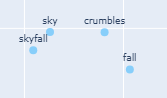

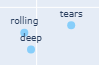

Acá se resalta la agrupación exacta de `set`,` rain` y `fire` (del éxito Set Fire to the Rain).

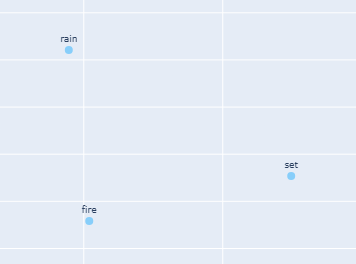

Acá se observan muy cerca `send`, `new` y `lover` (de Send My Love (To Your New Lover)).

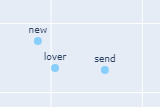

Acá el modelo asocia `rumor`, `has` y la interjección `ooh` (de Rumour Has It).

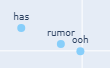

Y acá agrupó `river` y `lea` (por la canción River Lea).

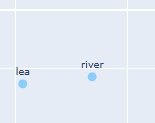

**2. Agrupaciones Sintácticas y Funcionales**

Word2Vec logró separar palabras según la función gramatical que cumplen en los versos, acercándolas porque estadísticamente están rodeadas del mismo tipo de vocabulario:

* **Verbos de percepción y sentidos:** Se agruparon verbos como `hear`,` feel`, `look` y `make`.

  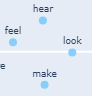

* **Verbos de deseo, necesidad y obligación:** Términos como `we've` y `gotta` quedaron juntos, al igual que `do`, `need` y `want`.

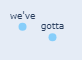

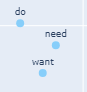

* **Partículas y preposiciones direccionales:** El modelo identificó la anatomía de los phrasal verbs ingleses, juntando términos como `put`, `through`, `turn`, `out` e `in`.

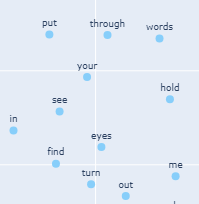

* **Tiempos perfectos y conocimiento:** Agrupó `i've`, `met` y `known`, demostrando que reconoce los participios que le siguen al verbo auxiliar.

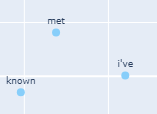

**3. Similitud Semántica y Temática**


Finalmente, el modelo agrupa conceptos que representan las ideas centrales de sus canciones, usadas de manera intercambiable para construir su narrativa emocional:


* Conceptos de vulnerabilidad y pensamiento profundo como `mind`, `help` y `leave`. También el grupo nocturno y de melancolía: `lights`, `miss` y `baby`.

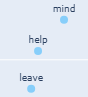

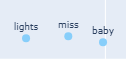

* El grupo de superación y postura, uniendo `how`, `tall` y `stand` (probablemente conectadas semánticamente a frases de resistencia o a la frase "stand tall" de Skyfall).

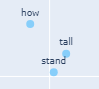

### **Conclusión del desafío:**

El entrenamiento de Custom Embeddings con Gensim sobre las letras de Adele demuestra empíricamente cómo la arquitectura Skip-gram mapea no solo la semántica (significado) de las palabras, sino también la sintaxis (gramática) y las colocaciones (frases hechas). Los vectores generados capturan a la perfección la "huella de estilo" de la artista, siendo la reducción de dimensionalidad con t-SNE una herramienta excelente para visualizar cómo el algoritmo ha "entendido" sus letras.